In [ ]:
!curl -L -o ./ravdess-audio.zip https://www.kaggle.com/api/v1/datasets/download/uwrfkaggler/ravdess-emotional-speech-audio
!mkdir audio_files
!unzip ./ravdess-audio.zip
!mv ./audio_speech_actors_01-24/*/* ./audio_files/
!rm -r ./Actor* ./audio_speech_actors_01-24

In [6]:
!git clone https://github.com/karolpiczak/ESC-50.git

fatal: destination path 'ESC-50' already exists and is not an empty directory.


In [ ]:
import os
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import joblib
import numpy as np
import pandas as pd
import librosa

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("metadata.csv")
df.head()

,file_name,emotion,intensity,gender,statement,duration
0,03-01-05-01-02-01-16,angry,normal,female,Dogs are sitting by the door,3.903896
1,03-01-08-01-01-01-14,surprised,normal,female,Kids are talking by the door,3.636979
2,03-01-05-01-02-01-02,angry,normal,female,Dogs are sitting by the door,3.770417
3,03-01-02-01-02-01-12,calm,normal,female,Dogs are sitting by the door,3.770437
4,03-01-02-01-02-01-06,calm,normal,female,Dogs are sitting by the door,3.970625


In [ ]:
def extract_features(file_path):
    nmfcc = 13
    y, _ = librosa.load(file_path, sr=sample_rate, mono=True)
    mfcc   = librosa.feature.mfcc(y=y, sr=sample_rate, n_mfcc=nmfcc)
    chroma = librosa.feature.chroma_stft(S=np.abs(librosa.stft(y)), sr=sample_rate)
    rms    = librosa.feature.rms(y=y)
    return np.hstack([mfcc.mean(axis=1), mfcc.std(axis=1),chroma.mean(axis=1), 
                      chroma.std(axis=1),rms.mean(), rms.std()]) 

In [31]:
sample_rate     = 22050

X, y_raw = [], []
for _, row in full_df.iterrows():
    folder = out_dir if row["augmentation"] != "original" else in_dir
    if "wav" in row["file_name"]:
      path   = os.path.join(folder, row["file_name"])
    else:
      path   = os.path.join(folder, row["file_name"]+".wav")

    X.append(extract_features(path))
    y_raw.append(row["emotion"])

X     = np.array(X)
y_raw = np.array(y_raw)
print(f"Feature matrix: {X.shape}  |  Labels: {np.unique(y_raw)}")

le      = LabelEncoder()
y       = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

joblib.dump(scaler,"svm_scaler.gz")

Feature matrix: (3600, 52)  |  Labels: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


['svm_scaler.gz']

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
              precision    recall  f1-score   support

       angry       0.68      0.73      0.70        96
        calm       0.64      0.75      0.69        96
     disgust       0.62      0.74      0.67        96
     fearful       0.62      0.58      0.60        96
       happy       0.68      0.62      0.65        96
     neutral       0.52      0.46      0.49        48
         sad       0.57      0.54      0.55        96
   surprised       0.66      0.53      0.59        96

    accuracy                           0.63       720
   macro avg       0.62      0.62      0.62       720
weighted avg       0.63      0.63      0.63       720



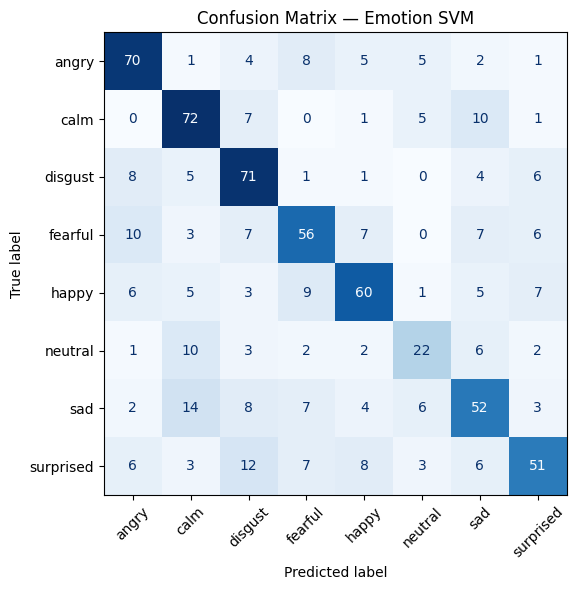

In [32]:
param_grid = {
    "C":     [0.1, 1, 10, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1],
    "kernel": ['rbf','sigmoid'], 
}

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm = GridSearchCV(
    SVC(class_weight="balanced", probability=True),
    param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)

svm.fit(X_train, y_train)
print(f"\nBest params : {svm.best_params_}")

y_pred = svm.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45
)
ax.set_title("Confusion Matrix — Emotion SVM")
plt.tight_layout()
plt.show()

In [33]:
import pickle

In [34]:
with open('model.pkl','wb') as f:
    pickle.dump(svm,f)

scaler = joblib.load("svm_scaler.gz")

In [ ]:
classes = le.classes_
for dir,_,files in os.walk("./own_voice"):
    for f in files:
        feature = extract_features(f"{dir}/{f}")
        feature_scaled = scaler.transform([feature])
        prediction = svm.predict(feature_scaled).item()
        print(f"File: {f}, prediction: {classes[prediction]}")

File: Calm2.wav, prediction: fearful
File: Calm1.wav, prediction: happy
File: Angry1.wav, prediction: angry
File: Angry2.wav, prediction: happy
File: Disgust1.wav, prediction: happy
File: Fear1.wav, prediction: happy
File: Disgust2.wav, prediction: happy
File: Fear2.wav, prediction: fearful
File: Surprised1.wav, prediction: happy
File: Sad2.wav, prediction: fearful
File: Surprised2.wav, prediction: happy
File: Sad1.wav, prediction: happy
File: Happy1.wav, prediction: surprised
File: Neutral1.wav, prediction: surprised
File: Happy2.wav, prediction: surprised
File: Neutral2.wav, prediction: surprised


In [45]:
feature = extract_features("12_Angry_Men.wav")
feature_scaled = scaler.transform([feature])
prediction = svm.predict(feature_scaled).item()
print(f"True Class: angry, Prediction: {classes[prediction]}")

True Class: angry, Prediction: angry
